In [10]:
# =============
# CARGA DE LIBRERIAS

import gc
import matplotlib.colors as colors
import matplotlib.pyplot as plt
import numpy as np
import os
import pickle
from sklearn.preprocessing import StandardScaler
import torch

In [ ]:
# =============
# EXTRACCIÓN Y PROCESAMIENTO DE LOS DATASETS DE ENTRENAMIENTO

# Directorio y parámetros generales
data_dir       = "data"
extra_dir      = "extra"
num_cols       = 5000
total_samples  = 3372890

# Mapeo de los tres archivos completos
flux_mm       = np.memmap(os.path.join(data_dir, "spectra_data_complete_flux.dat"),
                         dtype='float32', mode='r').reshape(total_samples, num_cols)
wave_mm       = np.memmap(os.path.join(data_dir, "spectra_data_complete_wavelength.dat"),
                         dtype='float32', mode='r').reshape(total_samples, num_cols)
redshift_mm   = np.memmap(os.path.join(data_dir, "spectra_data_complete_redshift.dat"),
                         dtype='float32', mode='r')

# Requerimientos para TRAIN: exactos por rango (números pseudoaleatorios)
train_required = {
    (0, 0.1):    66740,
    (0.1, 1):    361237,
    (1,   2):    27893,
    (2,   3):    32576,
    (3,   4):    11750,
    (4,   8):    4528,
}

# Muestreo estratificado para TRAIN (sin ningún filtrado previo)
train_idxs = []
for (lo, hi), count in train_required.items():
    # candidatos en el rango [lo, hi)
    cand = np.where((redshift_mm >= lo) & (redshift_mm < hi))[0]
    if len(cand) < count:
        print(f"[TRAIN] Rango [{lo}, {hi}): solo {len(cand)} disponibles, tomo todas.")
        sel = cand
    else:
        sel = np.random.choice(cand, size=count, replace=False)
    train_idxs.append(sel)
train_idxs = np.concatenate(train_idxs)

train_data = {
    "flux":     flux_mm[train_idxs],
    "wavelength": wave_mm[train_idxs],
    "redshift": redshift_mm[train_idxs].astype(np.float32).reshape(-1,1)
}

# Requerimientos para TEST: exactos por rango y disjuntos de TRAIN (números pseudoaleatorios)
test_required = {
    (0, 0.1):    12692,
    (0.1, 1):    68890,
    (1,   2):    5214,
    (2,   3):    6168,
    (3,   4):    2312,
    (4,   8):    0,
}

remaining = np.setdiff1d(np.arange(total_samples), train_idxs, assume_unique=True)

test_idxs = []
for (lo, hi), count in test_required.items():
    # de los índices remanentes, filtrar por rango
    cand = remaining[(redshift_mm[remaining] >= lo) & (redshift_mm[remaining] < hi)]
    if len(cand) < count:
        print(f"[TEST ] Rango [{lo}, {hi}): solo {len(cand)} disponibles, tomo todas.")
        sel = cand
    else:
        sel = np.random.choice(cand, size=count, replace=False)
    test_idxs.append(sel)
test_idxs = np.concatenate(test_idxs)

test_data = {
    "flux":     flux_mm[test_idxs],
    "wavelength": wave_mm[test_idxs],
    "redshift": redshift_mm[test_idxs].astype(np.float32).reshape(-1,1)
}

In [ ]:
# Escalado y guardado de los datos

# Instanciar los dos scalers
scaler_path = os.path.join(extra_dir, "scaler_stars_fitted.pkl")
flux_scaler = StandardScaler()           # para normalizar los datos de flux
wavelength_scaler = StandardScaler()     # para normalizar los datos de wavelength

# Ajustar cada scaler con los datos de entrenamiento correspondientes
flux_scaler.fit(train_data["flux"])
wavelength_scaler.fit(train_data["wavelength"])

# Guardar ambos scalers en pickle (persistencia de parámetros aprendidos)
scaler_dict = {
    "flux_scaler": flux_scaler,
    "wavelength_scaler": wavelength_scaler
}
with open(scaler_path, "wb") as f:
    pickle.dump(scaler_dict, f)
print(f"Scalers guardados en {scaler_path}")

# Transformar (normalizar) train y test usando los scalers adecuados
flux_train_scaled = flux_scaler.transform(train_data["flux"])
flux_test_scaled  = flux_scaler.transform(test_data["flux"])
wave_train_scaled = wavelength_scaler.transform(train_data["wavelength"])
wave_test_scaled  = wavelength_scaler.transform(test_data["wavelength"])

# Convertir a tensores torch (float32)
train_600k = {
    "flux":       torch.from_numpy(flux_train_scaled).float(),
    "wavelength": torch.from_numpy(wave_train_scaled).float(),
    "redshift":   torch.from_numpy(train_data["redshift"]).float()
}
test_600k = {
    "flux":       torch.from_numpy(flux_test_scaled).float(),
    "wavelength": torch.from_numpy(wave_test_scaled).float(),
    "redshift":   torch.from_numpy(test_data["redshift"]).float()
}

# 6) Guardar los datasets resultantes
torch.save(train_600k, os.path.join(data_dir, "train_dataset_600k.pt"))
torch.save(test_600k,  os.path.join(data_dir, "test_dataset_600k.pt"))

Scalers guardados en extra\scaler_stars_fitted.pkl


In [ ]:
# Conteo objetivo tras la ampliación
test_target = {
    (0, 0.1):    32732,
    (0.1, 1):    251162,
    (1,   2):    175701,
    (2,   3):    112582,
    (3,   4):    18659,
    (4,   8):    4440,
}

# Preparar candidatos: cualquier índice que NO esté en test_idxs (puede incluir train_idxs)
all_idxs  = np.arange(total_samples)
remaining = np.setdiff1d(all_idxs, test_idxs, assume_unique=True)

# Para cada rango, muestrear el déficit
additional = []
for (lo, hi), target in test_target.items():
    have = test_required[(lo, hi)]
    need = target - have
    if need <= 0:
        continue

    # Filtrar candidatos en este rango de redshift
    mask = (redshift_mm[remaining] >= lo) & (redshift_mm[remaining] < hi)
    cand = remaining[mask]

    # Si hay menos candidatos que necesidad, tomamos todos; si no, muestreamos aleatoriamente
    if len(cand) < need:
        print(f"[WARN] Rango [{lo}, {hi}): solo {len(cand)} candidatos, añadiendo todos.")
        sel = cand
    else:
        sel = np.random.choice(cand, size=need, replace=False)

    additional.append(sel)

# Actualizar test_idxs con los nuevos índices
if additional:
    additional = np.concatenate(additional)
    test_idxs   = np.concatenate([test_idxs, additional])

# Reconstruir y escalar el dataset ampliado
flux_scaled = flux_scaler.transform( flux_mm[test_idxs] )
wave_scaled = wavelength_scaler.transform( wave_mm[test_idxs] )

test_1M = {
    "flux":       torch.from_numpy(flux_scaled).float(),          # normalizado con scaler_flux
    "wavelength": torch.from_numpy(wave_scaled).float(),          # normalizado con scaler_wave
    "redshift":   torch.from_numpy(
                      redshift_mm[test_idxs]
                      .astype(np.float32)
                      .reshape(-1,1)
                  ).float()                                        # reshape a [N,1]
}

# Guardar el test ampliado
torch.save(test_1M, os.path.join(data_dir, "test_dataset_1M.pt"))

[WARN] Rango [0, 0.1): solo 279989 candidatos, añadiendo todos.


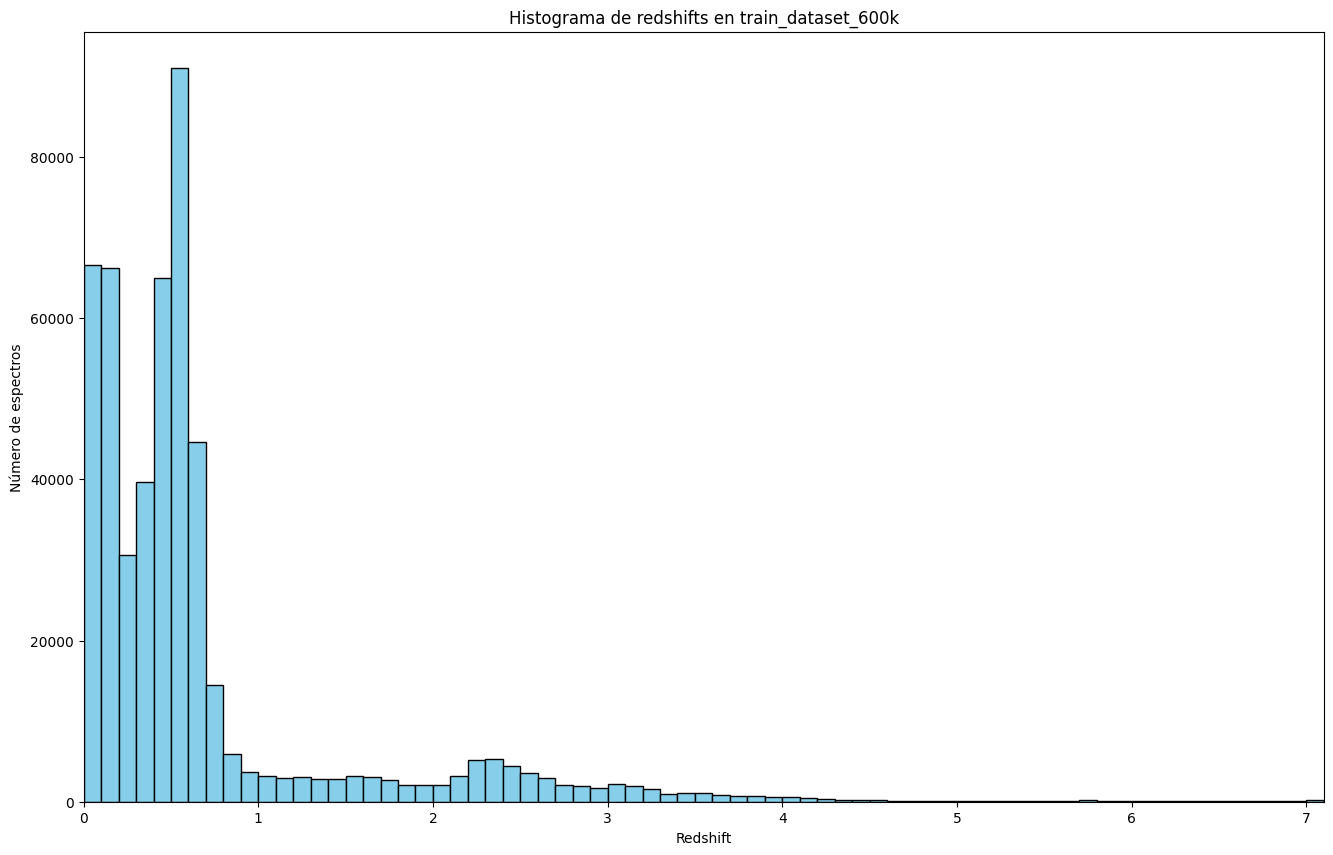

In [ ]:
# Directorio donde se encuentra el archivo .pt
data_dir = "data"  # Actualiza esta ruta según corresponda
dataset_path = os.path.join(data_dir, "train_dataset_600k.pt")

# Cargar el dataset test_dataset_2.pt
test_dataset = torch.load(dataset_path)

# Extraer el tensor de redshifts y convertirlo a array de NumPy
# Se asume que tiene forma [N, 1] y se utiliza squeeze() para convertirlo a 1D
redshift_array = test_dataset["redshift"].squeeze().numpy()
print("Número de espectros:", len(redshift_array))

# Definir los bins para el histograma (ancho de bin = 0.1)
bins = np.arange(0, redshift_array.max() + 0.1, 0.1)

# Crear y mostrar el histograma
plt.figure(figsize=(16,10))
plt.hist(redshift_array, bins=bins, color='skyblue', edgecolor='black')
plt.xlabel("Redshift")
plt.ylabel("Número de espectros")
plt.title("Histograma de redshifts en train_dataset_600k")
plt.xlim(0, 7.1)
plt.show()

In [ ]:
# =============
# PROCESAMIENTO DEL CONJUNTO COMPLETO DE DATOS

# Parámetros generales
data_dir = "data2"                      # Directorio donde se encuentran y se guardarán los datos
extra_dir = "extra"                    # Directorio donde se encuentra el scaler
os.makedirs(extra_dir, exist_ok=True)  # Asegurarse que extra existe
total_complete = 3372890               # Número total de espectros en el dataset completo
num_points = 5000                      # Número de puntos por espectro
chunk_size = 10000                     # Tamaño del chunk para procesamiento
split_index = total_complete // 2      # Índice para dividir en dos mitades (necesario ya que al cargarlo al completo supera el límite de memoria)

# Cargar Scalers
scaler_filename = os.path.join(extra_dir, "scaler_fitted.pkl")
with open(scaler_filename, "rb") as f:
    scaler_dict = pickle.load(f)
flux_scaler = scaler_dict["flux_scaler"]
wavelength_scaler = scaler_dict["wavelength_scaler"]

# Crear memmaps de los datos no procesados

complete_flux_path     = os.path.join(data_dir, "spectra_data_complete_flux.dat")
complete_wave_path     = os.path.join(data_dir, "spectra_data_complete_wavelength.dat")
complete_redshift_path = os.path.join(data_dir, "spectra_data_complete_redshift.dat")

flux_complete = np.memmap(complete_flux_path, dtype="float32", mode="r", shape=(total_complete, num_points))
wavelength_complete = np.memmap(complete_wave_path, dtype="float32", mode="r", shape=(total_complete, num_points))
redshift_complete = np.memmap(complete_redshift_path, dtype="float32", mode="r", shape=(total_complete,))

# Se crean memmaps para almacenar los datos escalados
flux_scaled_path = os.path.join(data_dir, "flux_complete_scaled.dat")
wavelength_scaled_path = os.path.join(data_dir, "wavelength_complete_scaled.dat")

flux_complete_scaled = np.memmap(flux_scaled_path, dtype="float32", mode="w+", shape=(total_complete, num_points))
wavelength_complete_scaled = np.memmap(wavelength_scaled_path, dtype="float32", mode="w+", shape=(total_complete, num_points))

print("Normalizando flux y wavelength en bloques...")
for start in range(0, total_complete, chunk_size):
    end = min(start + chunk_size, total_complete)
    # Aplicar escalado a cada chunk
    flux_complete_scaled[start:end] = flux_scaler.transform(flux_complete[start:end])
    wavelength_complete_scaled[start:end] = wavelength_scaler.transform(wavelength_complete[start:end])
    print(f"Procesado de índices {start} a {end}")

# Asegurarse de escribir en disco y liberar memoria
flux_complete_scaled.flush()
wavelength_complete_scaled.flush()
del flux_complete, wavelength_complete
gc.collect()

# Rutas para los memmaps de salida de cada mitad
flux1_memmap_path       = os.path.join(data_dir, "flux1.dat")
flux2_memmap_path       = os.path.join(data_dir, "flux2.dat")
wavelength1_memmap_path = os.path.join(data_dir, "wavelength1.dat")
wavelength2_memmap_path = os.path.join(data_dir, "wavelength2.dat")
redshift1_memmap_path   = os.path.join(data_dir, "redshift1.dat")
redshift2_memmap_path   = os.path.join(data_dir, "redshift2.dat")

# Crear los memmaps para cada mitad
flux1_memmap       = np.memmap(flux1_memmap_path, dtype="float32", mode="w+", shape=(split_index, num_points))
flux2_memmap       = np.memmap(flux2_memmap_path, dtype="float32", mode="w+", shape=(total_complete - split_index, num_points))
wavelength1_memmap = np.memmap(wavelength1_memmap_path, dtype="float32", mode="w+", shape=(split_index, num_points))
wavelength2_memmap = np.memmap(wavelength2_memmap_path, dtype="float32", mode="w+", shape=(total_complete - split_index, num_points))
redshift1_memmap   = np.memmap(redshift1_memmap_path, dtype="float32", mode="w+", shape=(split_index,))
redshift2_memmap   = np.memmap(redshift2_memmap_path, dtype="float32", mode="w+", shape=(total_complete - split_index,))

# Abrir los memmaps escalados en modo lectura
flux_scaled       = np.memmap(flux_scaled_path, dtype="float32", mode="r", shape=(total_complete, num_points))
wavelength_scaled = np.memmap(wavelength_scaled_path, dtype="float32", mode="r", shape=(total_complete, num_points))
redshift_complete = np.memmap(complete_redshift_path, dtype="float32", mode="r", shape=(total_complete,))  # Redshift se encuentra en el archivo original, no se escala

print("Dividiendo el dataset en dos mitades en bloques...")
for start in range(0, total_complete, chunk_size):
    end = min(start + chunk_size, total_complete)

    # Procesar flux
    flux_chunk = flux_scaled[start:end]
    if end <= split_index:
        flux1_memmap[start:end] = flux_chunk
    elif start >= split_index:
        flux2_memmap[start - split_index: end - split_index] = flux_chunk
    else:
        flux1_memmap[start:split_index] = flux_chunk[:split_index - start]
        flux2_memmap[0: end - split_index] = flux_chunk[split_index - start:]
    
    # Procesar wavelength
    wavelength_chunk = wavelength_scaled[start:end]
    if end <= split_index:
        wavelength1_memmap[start:end] = wavelength_chunk
    elif start >= split_index:
        wavelength2_memmap[start - split_index: end - split_index] = wavelength_chunk
    else:
        wavelength1_memmap[start:split_index] = wavelength_chunk[:split_index - start]
        wavelength2_memmap[0: end - split_index] = wavelength_chunk[split_index - start:]
    
    # Procesar redshift (1D)
    redshift_chunk = redshift_complete[start:end]
    if end <= split_index:
        redshift1_memmap[start:end] = redshift_chunk
    elif start >= split_index:
        redshift2_memmap[start - split_index: end - split_index] = redshift_chunk
    else:
        redshift1_memmap[start:split_index] = redshift_chunk[:split_index - start]
        redshift2_memmap[0: end - split_index] = redshift_chunk[split_index - start:]
    
    if start % (chunk_size * 10) == 0:
        print(f"Dividido índices {start} a {end}")

# Asegurar escritura en disco y liberar memoria
flux1_memmap.flush(); flux2_memmap.flush()
wavelength1_memmap.flush(); wavelength2_memmap.flush()
redshift1_memmap.flush(); redshift2_memmap.flush()
del flux_scaled, wavelength_scaled, redshift_complete
torch.cuda.empty_cache()
gc.collect()

# Convertimos ahora los memmaps divididos a tensores y guardamos

print("Convirtiendo y guardando los fluxes a tensores...")

# Flux
flux1_tensor = torch.from_numpy(np.array(np.memmap(flux1_memmap_path, dtype="float32", mode="r", shape=(split_index, num_points))))
flux2_tensor = torch.from_numpy(np.array(np.memmap(flux2_memmap_path, dtype="float32", mode="r", shape=(total_complete - split_index, num_points))))
torch.save(flux1_tensor, os.path.join(data_dir, "flux1.pt"))
torch.save(flux2_tensor, os.path.join(data_dir, "flux2.pt"))

del flux1_tensor, flux2_tensor
torch.cuda.empty_cache()
gc.collect()

print("Convirtiendo y guardando los wavelengths a tensores...")

# Wavelength
wavelength1_tensor = torch.from_numpy(np.array(np.memmap(wavelength1_memmap_path, dtype="float32", mode="r", shape=(split_index, num_points))))
wavelength2_tensor = torch.from_numpy(np.array(np.memmap(wavelength2_memmap_path, dtype="float32", mode="r", shape=(total_complete - split_index, num_points))))
torch.save(wavelength1_tensor, os.path.join(data_dir, "wavelength1.pt"))
torch.save(wavelength2_tensor, os.path.join(data_dir, "wavelength2.pt"))

del wavelength1_tensor, wavelength2_tensor
torch.cuda.empty_cache()
gc.collect()

# Redshift (ajustamos aquí a dimensiones [N, 1])
redshift1_tensor = torch.from_numpy(np.array(np.memmap(redshift1_memmap_path, dtype="float32", mode="r", shape=(split_index,)))).unsqueeze(1)
redshift2_tensor = torch.from_numpy(np.array(np.memmap(redshift2_memmap_path, dtype="float32", mode="r", shape=(total_complete - split_index,)))).unsqueeze(1)
torch.save(redshift1_tensor, os.path.join(data_dir, "redshift1.pt"))
torch.save(redshift2_tensor, os.path.join(data_dir, "redshift2.pt"))

print("Proceso completado. Archivos finales guardados exitosamente.")

Normalizando flux y wavelength en bloques...
Procesado de índices 0 a 10000
Procesado de índices 10000 a 20000
Procesado de índices 20000 a 30000
Procesado de índices 30000 a 40000
Procesado de índices 40000 a 50000
Procesado de índices 50000 a 60000
Procesado de índices 60000 a 70000
Procesado de índices 70000 a 80000
Procesado de índices 80000 a 90000
Procesado de índices 90000 a 100000
Procesado de índices 100000 a 110000
Procesado de índices 110000 a 120000
Procesado de índices 120000 a 130000
Procesado de índices 130000 a 140000
Procesado de índices 140000 a 150000
Procesado de índices 150000 a 160000
Procesado de índices 160000 a 170000
Procesado de índices 170000 a 180000
Procesado de índices 180000 a 190000
Procesado de índices 190000 a 200000
Procesado de índices 200000 a 210000
Procesado de índices 210000 a 220000
Procesado de índices 220000 a 230000
Procesado de índices 230000 a 240000
Procesado de índices 240000 a 250000
Procesado de índices 250000 a 260000
Procesado de índ

In [ ]:
# # Parámetros y rutas
# data_dir = "data"
# big_total = 595472     # Número de espectros en bigtraining
# small_total = 4528     # Número de espectros en smalltraining
# num_points = 5000      # Número de puntos por espectro

# # Rutas originales de los datos
# big_flux_path = os.path.join(data_dir, "spectra_data_bigtraining_flux.dat")
# big_wavelength_path = os.path.join(data_dir, "spectra_data_bigtraining_wavelength.dat")
# small_flux_path = os.path.join(data_dir, "spectra_data_smalltraining_flux.dat")
# small_wavelength_path = os.path.join(data_dir, "spectra_data_smalltraining_wavelength.dat")

# # Rutas de salida para los datos normalizados
# big_flux_norm_path = os.path.join(data_dir, "spectra_data_bigtraining_flux_norm.dat")
# big_wavelength_norm_path = os.path.join(data_dir, "spectra_data_bigtraining_wavelength_norm.dat")
# small_flux_norm_path = os.path.join(data_dir, "spectra_data_smalltraining_flux_norm.dat")
# small_wavelength_norm_path = os.path.join(data_dir, "spectra_data_smalltraining_wavelength_norm.dat")

# # Cargar el scaler previamente ajustado
# scaler_path = os.path.join("extra", "scaler_modelCNN_UPD_fitted.pkl")
# with open(scaler_path, 'rb') as f:
#     scaler = pickle.load(f)
# print("Scaler cargado desde:", scaler_path)

# def normalize_and_save(flux_path, wavelength_path, total, output_flux_path, output_wavelength_path, batch_size=1024):
#     """
#     Normaliza los datos de flujo y longitud de onda y los guarda en nuevos archivos.
#     Se procesan en batches para evitar problemas de memoria.
#     """
#     # Abrir los archivos originales usando memmap
#     flux_mem = np.memmap(flux_path, dtype="float32", mode="r", shape=(total, num_points))
#     wavelength_mem = np.memmap(wavelength_path, dtype="float32", mode="r", shape=(total, num_points))
    
#     # Crear archivos de salida en modo escritura
#     norm_flux = np.memmap(output_flux_path, dtype="float32", mode="w+", shape=(total, num_points))
#     norm_wavelength = np.memmap(output_wavelength_path, dtype="float32", mode="w+", shape=(total, num_points))
    
#     # Procesar por batches
#     for i in range(0, total, batch_size):
#         i_end = min(i + batch_size, total)
#         # Leer batch
#         batch_flux = flux_mem[i:i_end].copy()         # shape: (batch_size, num_points)
#         batch_wavelength = wavelength_mem[i:i_end].copy() # shape: (batch_size, num_points)
#         # Combinar en un array con dos canales: (batch_size, 2, num_points)
#         batch_X = np.stack([batch_flux, batch_wavelength], axis=1)
#         # Aplanar cada muestra a (1, 2*num_points)
#         batch_X_flat = batch_X.reshape(batch_X.shape[0], -1)
#         # Aplicar la transformación con el scaler
#         batch_X_scaled_flat = scaler.transform(batch_X_flat)
#         # Reconstruir la forma original (batch_size, 2, num_points)
#         batch_X_scaled = batch_X_scaled_flat.reshape(batch_X.shape[0], 2, num_points)
#         # Separar canales: el primero es flujo, el segundo longitud de onda
#         norm_flux[i:i_end] = batch_X_scaled[:, 0, :]
#         norm_wavelength[i:i_end] = batch_X_scaled[:, 1, :]
        
#         print(f"Procesados los samples {i} a {i_end}", flush=True)
    
#     # Asegurar que se guarden los datos en disco
#     norm_flux.flush()
#     norm_wavelength.flush()

# # Normalizar y guardar datos para bigtraining
# normalize_and_save(big_flux_path, big_wavelength_path, big_total, big_flux_norm_path, big_wavelength_norm_path, batch_size=1024)

# # Normalizar y guardar datos para smalltraining
# normalize_and_save(small_flux_path, small_wavelength_path, small_total, small_flux_norm_path, small_wavelength_norm_path, batch_size=1024)

# print("Normalización y guardado completados.")

Flux raw shape: (1649945000,)
Wavelength raw shape: (1649945000,)
Flux 2D shape: (329989, 5000)
Wavelength 2D shape: (329989, 5000)
Nuevos archivos memmap 2D creados:
  Flux: data\spectra_data_stars_flux_2d.dat
  Wavelength: data\spectra_data_stars_wavelength_2d.dat
Flux 2D shape: (329989, 5000)
Wavelength 2D shape: (329989, 5000)


In [ ]:
# # Definir el Dataset
# class SpectraDataset(Dataset):
#     def __init__(self, flux_path, wavelength_path, redshift_path, total, num_points, scaler=None):
#         """
#         Parámetros:
#           flux_path, wavelength_path, redshift_path: rutas a los archivos .dat
#           total: número total de espectros
#           num_points: número de puntos por espectro
#           scaler: si se pasa, se aplica la transformación (espera un objeto StandardScaler)
#         """
#         self.flux = np.memmap(flux_path, dtype="float32", mode="r", shape=(total, num_points))
#         self.wavelength = np.memmap(wavelength_path, dtype="float32", mode="r", shape=(total, num_points))
#         self.redshift = np.memmap(redshift_path, dtype="float32", mode="r", shape=(total,))
#         self.total = total
#         self.num_points = num_points
#         self.scaler = scaler

#     def __len__(self):
#         return self.total

#     def __getitem__(self, idx):
#         # Leer la muestra individualmente
#         flux_sample = self.flux[idx, :].copy()
#         wave_sample = self.wavelength[idx, :].copy()
#         # Combinar en un array de forma (2, num_points)
#         X = np.stack([flux_sample, wave_sample], axis=0)
#         # Si se pasó un scaler, se aplica la transformación
#         if self.scaler is not None:
#             X_flat = X.reshape(1, -1)
#             X_scaled_flat = self.scaler.transform(X_flat)
#             X = X_scaled_flat.reshape(2, self.num_points)
#         # Leer el redshift
#         y = self.redshift[idx]
#         # Convertir a tensores de PyTorch
#         X_tensor = torch.tensor(X, dtype=torch.float32)
#         # Se aplica unsqueeze para que el target tenga forma (1,)
#         y_tensor = torch.tensor(y, dtype=torch.float32).unsqueeze(0)
#         return X_tensor, y_tensor

# # Parámetros y rutas
# device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# print(f"Usando dispositivo: {device}")

# data_dir = "data"
# num_points = 5000

# # Parámetros de tamaño
# big_total = 595472     # Número de espectros en bigtraining
# small_total = 4528     # Número de espectros en smalltraining

# # Rutas de los archivos bigtraining
# big_flux_path = os.path.join(data_dir, "spectra_data_bigtraining_flux.dat")
# big_wavelength_path = os.path.join(data_dir, "spectra_data_bigtraining_wavelength.dat")
# big_redshift_path = os.path.join(data_dir, "spectra_data_bigtraining_redshift.dat")

# # Rutas de los archivos smalltraining
# small_flux_path = os.path.join(data_dir, "spectra_data_smalltraining_flux.dat")
# small_wavelength_path = os.path.join(data_dir, "spectra_data_smalltraining_wavelength.dat")
# small_redshift_path = os.path.join(data_dir, "spectra_data_smalltraining_redshift.dat")

# # # Crear los Datasets sin normalización para ajustar el scaler (comentado para no volver a hacer .fit)

# big_dataset = SpectraDataset(big_flux_path, big_wavelength_path, big_redshift_path, big_total, num_points, scaler=None)
# small_dataset = SpectraDataset(small_flux_path, small_wavelength_path, small_redshift_path, small_total, num_points, scaler=None)

# # # Dividir el conjunto bigtraining en train y test (84% train, 16% test)
# indices_big = np.arange(big_total)
# big_train_indices, big_test_indices = train_test_split(indices_big, test_size=0.16, random_state=42)

# big_train_dataset = Subset(big_dataset, big_train_indices)
# big_test_dataset = Subset(big_dataset, big_test_indices)

# # Conjunto de entrenamiento final: 84% de bigtraining + todo smalltraining
# train_dataset = ConcatDataset([big_train_dataset, small_dataset])
# test_dataset = big_test_dataset  # El test proviene solo de bigtraining

# # Ajustar el scaler de forma incremental
# scaler = StandardScaler()

# # Usamos un DataLoader para iterar en batches sobre el conjunto de entrenamiento sin normalizar
# loader_for_scaler = DataLoader(train_dataset, batch_size=1024, shuffle=False, num_workers=0)
# for batch in loader_for_scaler:
#     X_batch, _ = batch  # X_batch shape: (batch_size, 2, num_points)
#     X_batch_flat = X_batch.view(X_batch.size(0), -1).numpy()  # convertir a array de NumPy
#     scaler.partial_fit(X_batch_flat)

# # Guardar el scaler para usos futuros
# scaler_path = os.path.join("extra", "scaler_modelCNN_UPD_fitted.pkl")
# with open(scaler_path, "wb") as f:
#     pickle.dump(scaler, f)
# print("Scaler ajustado y guardado en:", scaler_path)

# # Cargar el scaler ya ajustado desde la ruta de guardado
# scaler_path = os.path.join("extra", "scaler_modelCNN_UPD_fitted.pkl")
# with open(scaler_path, 'rb') as f:
#     scaler = pickle.load(f)
# print("Scaler cargado desde:", scaler_path)

# # Crear los Datasets con el scaler ya ajustado, asignando el scaler para que en __getitem__ se aplique la normalización
# big_dataset_norm = SpectraDataset(big_flux_path, big_wavelength_path, big_redshift_path, big_total, num_points, scaler=scaler)
# small_dataset_norm = SpectraDataset(small_flux_path, small_wavelength_path, small_redshift_path, small_total, num_points, scaler=scaler)

# # Aplicar los mismos índices para los subconjuntos de bigtraining
# big_train_dataset_norm = Subset(big_dataset_norm, big_train_indices)
# big_test_dataset_norm = Subset(big_dataset_norm, big_test_indices)

# # Conjunto de entrenamiento final normalizado: 84% de bigtraining + todo smalltraining
# train_dataset = ConcatDataset([big_train_dataset_norm, small_dataset_norm])
# test_dataset = big_test_dataset_norm

# # Crear DataLoaders y pasar al dispositivo
# train_loader = DataLoader(train_dataset, shuffle=True)
# test_loader = DataLoader(test_dataset, shuffle=False)

# print("Listo para entrenar a partir de los datos con scaler ajustado y usando memmap de forma eficiente.")

In [ ]:
# # Directorio donde se encuentran los datasets
# data_dir = "data"  # Actualiza esta ruta según corresponda

# # Lista de archivos de los test datasets
# dataset_files = [
#     "test_dataset_1M.pt",
#     "test_dataset_2.pt",
#     "test_dataset_3.pt"
# ]

# # Inicializar listas para almacenar los tensores de cada clave
# flux_list = []
# wavelength_list = []
# redshift_list = []

# # Recorrer cada archivo, cargar el dataset y extraer sus tensores
# for filename in dataset_files:
#     dataset_path = os.path.join(data_dir, filename)
#     dataset = torch.load(dataset_path)
#     flux_list.append(dataset["flux"])
#     wavelength_list.append(dataset["wavelength"])
#     redshift_list.append(dataset["redshift"])

# # Concatenar cada tensor a lo largo de la dimensión 0
# flux_all = torch.cat(flux_list, dim=0)
# wavelength_all = torch.cat(wavelength_list, dim=0)
# redshift_all = torch.cat(redshift_list, dim=0)

# # Crear el diccionario del dataset consolidado
# merged_dataset = {
#     "flux": flux_all,
#     "wavelength": wavelength_all,
#     "redshift": redshift_all
# }

# # Guardar el dataset consolidado en un nuevo archivo .pt
# merged_dataset_path = os.path.join(data_dir, "test_dataset_1M2.pt")
# torch.save(merged_dataset, merged_dataset_path)
# print(f"Dataset consolidado guardado exitosamente en {merged_dataset_path}")

Dataset consolidado guardado exitosamente en data\test_dataset_1M2.pt


In [ ]:
# # Función para graficar un espectro aleatorio
# def plot_random_spectrum(flux, wavelength, title=""):
#     idx = np.random.randint(0, flux.shape[0])
#     plt.figure(figsize=(8,4))
#     plt.plot(wavelength[idx], flux[idx])
#     plt.xlabel("Wavelength")
#     plt.ylabel("Flux")
#     plt.title(f"{title} - Spectrum index {idx}")
#     plt.show()

# # Función para cargar datos usando np.memmap y copiarlos a memoria
# def load_data(file_flux, file_wave, file_redshift, total, num_points):
#     flux = np.memmap(file_flux, dtype="float32", mode="r", shape=(total, num_points))
#     wavelength = np.memmap(file_wave, dtype="float32", mode="r", shape=(total, num_points))
#     redshift = np.memmap(file_redshift, dtype="float32", mode="r", shape=(total,))
#     return np.array(flux), np.array(wavelength), np.array(redshift)

# # Parámetros generales
# data_dir = "data"
# num_points = 5000
# big_total = 595472    # Número de espectros en bigtraining
# small_total = 4528    # Número de espectros en smalltraining

# # Rutas de archivos para bigtraining (archivos sin normalizar)
# big_flux_path     = os.path.join(data_dir, "spectra_data_bigtraining_flux.dat")
# big_wave_path     = os.path.join(data_dir, "spectra_data_bigtraining_wavelength.dat")
# big_redshift_path = os.path.join(data_dir, "spectra_data_bigtraining_redshift.dat")

# # Rutas de archivos para smalltraining
# small_flux_path     = os.path.join(data_dir, "spectra_data_smalltraining_flux.dat")
# small_wave_path     = os.path.join(data_dir, "spectra_data_smalltraining_wavelength.dat")
# small_redshift_path = os.path.join(data_dir, "spectra_data_smalltraining_redshift.dat")

# # Cargar datos
# print("Cargando datos de bigtraining...")
# flux_big, wavelength_big, redshift_big = load_data(big_flux_path, big_wave_path, big_redshift_path, big_total, num_points)
# print("Cargando datos de smalltraining...")
# flux_small, wavelength_small, redshift_small = load_data(small_flux_path, small_wave_path, small_redshift_path, small_total, num_points)

# # Mostrar un espectro aleatorio de cada dataset (Raw)
# plot_random_spectrum(flux_big, wavelength_big, "Bigtraining (Raw)")
# plot_random_spectrum(flux_small, wavelength_small, "Smalltraining (Raw)")

# # Dividir bigtraining en train (84%) y test (16%)
# indices_big = np.arange(big_total)
# big_train_indices, big_test_indices = train_test_split(indices_big, test_size=0.16, random_state=42)

# flux_big_train      = flux_big[big_train_indices]
# wavelength_big_train = wavelength_big[big_train_indices]
# redshift_big_train   = redshift_big[big_train_indices]

# flux_big_test       = flux_big[big_test_indices]
# wavelength_big_test  = wavelength_big[big_test_indices]
# redshift_big_test    = redshift_big[big_test_indices]

# plot_random_spectrum(flux_big_train, wavelength_big_train, "Bigtraining Train (Raw)")
# plot_random_spectrum(flux_big_test, wavelength_big_test, "Bigtraining Test (Raw)")

# # Crear el conjunto de entrenamiento final: bigtraining_train + smalltraining
# flux_train = np.concatenate([flux_big_train, flux_small], axis=0)
# wavelength_train = np.concatenate([wavelength_big_train, wavelength_small], axis=0)
# redshift_train = np.concatenate([redshift_big_train, redshift_small], axis=0)

# plot_random_spectrum(flux_train, wavelength_train, "Conjunto de Entrenamiento Final (Raw)")

# # Convertir a float32 para reducir uso de memoria
# flux_train = flux_train.astype(np.float32)
# wavelength_train = wavelength_train.astype(np.float32)
# flux_big_test = flux_big_test.astype(np.float32)
# wavelength_big_test = wavelength_big_test.astype(np.float32)

# # Definir variables para el escalado incremental
# chunk_size = 10000  # Puedes ajustar este valor según la memoria disponible
# num_samples = flux_train.shape[0]
# print(f"Total de muestras en entrenamiento: {num_samples}")

# # Ajuste incremental de StandardScaler para flux y wavelength
# flux_scaler = StandardScaler()
# wavelength_scaler = StandardScaler()
# print("Ajustando escaladores en chunks...")
# for start in range(0, num_samples, chunk_size):
#     end = min(start + chunk_size, num_samples)
#     flux_scaler.partial_fit(flux_train[start:end])
#     wavelength_scaler.partial_fit(wavelength_train[start:end])

# # Transformar el conjunto de entrenamiento en chunks usando np.memmap para evitar asignación masiva en RAM
# flux_train_scaled = np.memmap("flux_train_scaled.dat", dtype="float32", mode="w+", shape=flux_train.shape)
# wavelength_train_scaled = np.memmap("wavelength_train_scaled.dat", dtype="float32", mode="w+", shape=wavelength_train.shape)
# print("Transformando conjunto de entrenamiento en chunks...")
# for start in range(0, num_samples, chunk_size):
#     end = min(start + chunk_size, num_samples)
#     flux_train_scaled[start:end] = flux_scaler.transform(flux_train[start:end])
#     wavelength_train_scaled[start:end] = wavelength_scaler.transform(wavelength_train[start:end])

# # Transformar el conjunto de test en chunks usando np.memmap
# num_samples_test = flux_big_test.shape[0]
# flux_test_scaled = np.memmap("flux_test_scaled.dat", dtype="float32", mode="w+", shape=flux_big_test.shape)
# wavelength_test_scaled = np.memmap("wavelength_test_scaled.dat", dtype="float32", mode="w+", shape=wavelength_big_test.shape)
# print("Transformando conjunto de test en chunks...")
# for start in range(0, num_samples_test, chunk_size):
#     end = min(start + chunk_size, num_samples_test)
#     flux_test_scaled[start:end] = flux_scaler.transform(flux_big_test[start:end])
#     wavelength_test_scaled[start:end] = wavelength_scaler.transform(wavelength_big_test[start:end])

# # Mostrar un espectro aleatorio del conjunto de entrenamiento escalado
# plot_random_spectrum(flux_train_scaled, wavelength_train_scaled, "Conjunto de Entrenamiento Final (Scaled)")

# # Convertir a tensores de PyTorch (cargando el memmap en array)
# train_data = {
#     "flux": torch.tensor(np.array(flux_train_scaled), dtype=torch.float32),
#     "wavelength": torch.tensor(np.array(wavelength_train_scaled), dtype=torch.float32),
#     "redshift": torch.tensor(redshift_train, dtype=torch.float32)
# }
# test_data = {
#     "flux": torch.tensor(np.array(flux_test_scaled), dtype=torch.float32),
#     "wavelength": torch.tensor(np.array(wavelength_test_scaled), dtype=torch.float32),
#     "redshift": torch.tensor(redshift_big_test, dtype=torch.float32)
# }

# # Guardar los datasets preprocesados
# torch.save(train_data, os.path.join(data_dir, "train_dataset.pt"))
# torch.save(test_data, os.path.join(data_dir, "test_dataset.pt"))
# print("Datasets guardados exitosamente.")

# # Guardar los escaladores ajustados en un diccionario y luego en un archivo pickle
# scaler_dict = {
#     "flux_scaler": flux_scaler,
#     "wavelength_scaler": wavelength_scaler
# }
# scaler_filename = os.path.join(data_dir, "scaler_modelCNN_UPD_fitted.pkl")
# with open(scaler_filename, "wb") as f:
#     pickle.dump(scaler_dict, f)
# print(f"Scalers guardados en {scaler_filename}")

# # Se utiliza torch.from_numpy() para evitar copiar todo el contenido del memmap a un array completo.
# # Además, se añade unsqueeze(1) al tensor de redshift para que tenga forma [N, 1].

# train_data = {
#     "flux": torch.from_numpy(flux_train_scaled),
#     "wavelength": torch.from_numpy(wavelength_train_scaled),
#     "redshift": torch.from_numpy(redshift_train.astype(np.float32)).unsqueeze(1)
# }
# test_data = {
#     "flux": torch.from_numpy(flux_test_scaled),
#     "wavelength": torch.from_numpy(wavelength_test_scaled),
#     "redshift": torch.from_numpy(redshift_big_test.astype(np.float32)).unsqueeze(1)
# }

# torch.save(train_data, os.path.join(data_dir, "train_dataset.pt"))
# torch.save(test_data, os.path.join(data_dir, "test_dataset.pt"))
# print("Datasets (train y test) guardados exitosamente usando torch.from_numpy().")

# # Guardar los escaladores ajustados en un diccionario y luego en un archivo pickle
# scaler_dict = {
#     "flux_scaler": flux_scaler,
#     "wavelength_scaler": wavelength_scaler
# }
# scaler_filename = "extra/scaler_600k_fitted.pkl"
# with open(scaler_filename, "wb") as f:
#     pickle.dump(scaler_dict, f)
# print(f"Scalers guardados en {scaler_filename}")

In [ ]:
# def plot_random_spectrum_from_dataset(dataset):
#     idx = random.randint(0, len(dataset) - 1)
#     input_sample, target = dataset[idx]
    
#     flux = input_sample[0].numpy()
#     wavelength = input_sample[1].numpy()
    
#     # Graficar el espectro
#     plt.figure(figsize=(20, 15))
#     plt.plot(wavelength, flux, label='Flux')
#     plt.xlabel('Wavelength')
#     plt.ylabel('Flux')
#     plt.title(f'Espectro aleatorio (índice {idx}) - Redshift: {target.item()}')
#     plt.legend()
#     plt.show()

# plot_random_spectrum_from_dataset(train_dataset)

# # Rutas de los datasets preprocesados
# data_dir = "data"
# train_dataset_path = os.path.join(data_dir, "train_dataset.pt")
# test_dataset_path  = os.path.join(data_dir, "test_dataset.pt")

# # Cargar los datasets
# train_data = torch.load(train_dataset_path)
# test_data = torch.load(test_dataset_path)

# # Extraer los redshifts
# redshifts_train = train_data["redshift"].numpy()
# redshifts_test = test_data["redshift"].numpy()

# # Definir bins para los rangos: 0-1, 1-2, ..., 7-8
# bins = np.arange(0, 9, 1)  # bins: [0, 1, 2, ..., 8]

# # Calcular histogramas
# train_hist, _ = np.histogram(redshifts_train, bins=bins)
# test_hist, _ = np.histogram(redshifts_test, bins=bins)

# # Imprimir los resultados para el conjunto de entrenamiento
# print("Distribución de redshifts en el conjunto de entrenamiento:")
# for i in range(len(train_hist)):
#     print(f"Rango {bins[i]} - {bins[i+1]}: {train_hist[i]}")

# # Imprimir los resultados para el conjunto de test
# print("\nDistribución de redshifts en el conjunto de test:")
# for i in range(len(test_hist)):
#     print(f"Rango {bins[i]} - {bins[i+1]}: {test_hist[i]}")

# Distribución de redshifts en el conjunto de entrenamiento:
# Rango 0 - 1: 427848
# Rango 1 - 2: 27893
# Rango 2 - 3: 32576
# Rango 3 - 4: 11750
# Rango 4 - 5: 2529
# Rango 5 - 6: 900
# Rango 6 - 7: 854
# Rango 7 - 8: 245

# Distribución de redshifts en el conjunto de test:
# Rango 0 - 1: 81553
# Rango 1 - 2: 5214
# Rango 2 - 3: 6168
# Rango 3 - 4: 2312
# Rango 4 - 5: 0
# Rango 5 - 6: 0
# Rango 6 - 7: 0
# Rango 7 - 8: 0

In [ ]:
# # Parámetros de configuración
# current_dataset_dir = 'data'      # Carpeta del dataset original
# desired_total = 600000            # Total deseado después de la ampliación
# num_points = 5000                 # Cada espectro tiene 5000 puntos

# # Rango de redshift para seleccionar nuevos espectros
# z_min = 0.0
# z_max = 8.0

# # Cargar los redshifts existentes del dataset actual
# current_redshift_path = os.path.join(current_dataset_dir, 'spectra_data_100k_redshift_mmap.dat')
# current_total = 460000  # Número actual de espectros
# current_redshifts = np.memmap(current_redshift_path, dtype='float32', mode='r', shape=(current_total,))
# existing_redshifts = set(current_redshifts.tolist())

# # Cargar el nuevo dataset (3M espectros) desde archivos .dat
# # Asumimos que los archivos nuevos se han guardado con np.memmap y tienen las siguientes rutas:
# new_flux_path = os.path.join(current_dataset_dir, 'spectra_data_complete_flux_mmap.dat')
# new_wavelength_path = os.path.join(current_dataset_dir, 'spectra_data_complete_wavelength_mmap.dat')
# new_redshift_path = os.path.join(current_dataset_dir, 'spectra_data_complete_redshift_mmap.dat')

# new_total_available = 3372890  # Total de espectros en el nuevo dataset

# # Cargar los memmaps del nuevo dataset en modo lectura
# new_flux = np.memmap(new_flux_path, dtype='float32', mode='r', shape=(new_total_available, num_points))
# new_wavelength = np.memmap(new_wavelength_path, dtype='float32', mode='r', shape=(new_total_available, num_points))
# new_redshifts = np.memmap(new_redshift_path, dtype='float32', mode='r', shape=(new_total_available,))

# new_flux_list = []
# new_wavelength_list = []
# new_redshift_list = []

# print("Filtrando nuevos espectros del dataset de 3M...")
# # Recorrer el nuevo dataset
# for i in range(new_total_available):
#     r = new_redshifts[i]
#     # Filtrar por rango de redshift
#     if r < z_min or r > z_max:
#         continue
#     # Evitar duplicados: se comprueba que el redshift no exista ya en el dataset original
#     if r in existing_redshifts:
#         continue
#     # Si cumple ambas condiciones, se añade la información
#     new_flux_list.append(new_flux[i, :].copy())         # .copy() para obtener un array independiente
#     new_wavelength_list.append(new_wavelength[i, :].copy())
#     new_redshift_list.append(r)
#     existing_redshifts.add(r)  # Agregar para evitar duplicados posteriores
    
#     # Si se alcanza el total deseado, se finaliza el filtrado
#     if current_total + len(new_redshift_list) >= desired_total:
#         break

# print(f"Se han encontrado {len(new_redshift_list)} nuevos espectros en el rango de redshift [{z_min}, {z_max}].")

# # Crear el nuevo dataset ampliado
# new_total = current_total + len(new_redshift_list)
# print(f"Dataset ampliado: {new_total} espectros.")

# # Rutas para los nuevos archivos memmap actualizados
# new_flux_mmap_path = os.path.join(current_dataset_dir, 'spectra_data_500k_flux_mmap.dat')
# new_wavelength_mmap_path = os.path.join(current_dataset_dir, 'spectra_data_500k_wavelength_mmap.dat')
# new_redshift_mmap_path = os.path.join(current_dataset_dir, 'spectra_data_500k_redshift_mmap.dat')

# # Preasignar los memmaps para el dataset ampliado
# flux_mmap_new = np.memmap(new_flux_mmap_path, dtype='float32', mode='w+', shape=(new_total, num_points))
# wavelength_mmap_new = np.memmap(new_wavelength_mmap_path, dtype='float32', mode='w+', shape=(new_total, num_points))
# redshift_mmap_new = np.memmap(new_redshift_mmap_path, dtype='float32', mode='w+', shape=(new_total,))

# # Copiar los datos antiguos del dataset actual
# current_flux_path = os.path.join(current_dataset_dir, 'spectra_data_450k_flux_mmap.dat')
# current_wavelength_path = os.path.join(current_dataset_dir, 'spectra_data_450k_wavelength_mmap.dat')

# flux_mmap_old = np.memmap(current_flux_path, dtype='float32', mode='r', shape=(current_total, num_points))
# wavelength_mmap_old = np.memmap(current_wavelength_path, dtype='float32', mode='r', shape=(current_total, num_points))

# # Copiar los datos del dataset original en los nuevos memmaps
# flux_mmap_new[:current_total, :] = flux_mmap_old[:]
# wavelength_mmap_new[:current_total, :] = wavelength_mmap_old[:]
# redshift_mmap_new[:current_total] = current_redshifts[:]

# # Añadir los nuevos espectros filtrados
# for i, (flux_array, wave_array, r) in enumerate(zip(new_flux_list, new_wavelength_list, new_redshift_list)):
#     idx = current_total + i
#     flux_mmap_new[idx, :] = flux_array
#     wavelength_mmap_new[idx, :] = wave_array
#     redshift_mmap_new[idx] = r

# # Asegurarse de que los cambios se guarden en disco
# flux_mmap_new.flush()
# wavelength_mmap_new.flush()
# redshift_mmap_new.flush()

# print("Se ha actualizado el dataset ampliado y se han guardado los nuevos archivos memmap.")

Filtrando nuevos espectros del dataset de 3M...
Se han encontrado 160000 nuevos espectros en el rango de redshift [0.0, 8.0].
Dataset ampliado: 620000 espectros.
Se ha actualizado el dataset ampliado y se han guardado los nuevos archivos memmap.


In [ ]:
# original_dir = 'data'
# num_points = 5000

# flux_orig_path = os.path.join(original_dir, 'spectra_data_trainingbig_flux.dat')
# wavelength_orig_path = os.path.join(original_dir, 'spectra_data_trainingbig_wavelength.dat')
# redshift_orig_path = os.path.join(original_dir, 'spectra_data_trainingbig_redshift.dat')
# # Total de espectros en el archivo original ampliado
# total_orig = 620000

# # Rango de redshift a trasladar
# z_min, z_max = 4.0, 8.0

# # Cargar los memmaps originales
# flux_orig = np.memmap(flux_orig_path, dtype='float32', mode='r', shape=(total_orig, num_points))
# wavelength_orig = np.memmap(wavelength_orig_path, dtype='float32', mode='r', shape=(total_orig, num_points))
# redshift_orig = np.memmap(redshift_orig_path, dtype='float32', mode='r', shape=(total_orig,))

# # Crear la máscara para el rango deseado
# mask = (redshift_orig >= z_min) & (redshift_orig <= z_max)
# indices_to_move = np.where(mask)[0]
# indices_to_keep = np.where(~mask)[0]

# print("Número de espectros a trasladar:", len(indices_to_move))
# print("Número de espectros restantes:", len(indices_to_keep))

# # Preasignar nuevos archivos memmap para el subconjunto filtrado
# subset_total = len(indices_to_move)
# new_flux_subset_path = os.path.join(original_dir, 'spectra_data_subset_flux_mmap.dat')
# new_wavelength_subset_path = os.path.join(original_dir, 'spectra_data_subset_wavelength_mmap.dat')
# new_redshift_subset_path = os.path.join(original_dir, 'spectra_data_subset_redshift_mmap.dat')

# flux_subset = np.memmap(new_flux_subset_path, dtype='float32', mode='w+', shape=(subset_total, num_points))
# wavelength_subset = np.memmap(new_wavelength_subset_path, dtype='float32', mode='w+', shape=(subset_total, num_points))
# redshift_subset = np.memmap(new_redshift_subset_path, dtype='float32', mode='w+', shape=(subset_total,))

# # Copiar las filas filtradas a los nuevos archivos
# for new_idx, orig_idx in enumerate(indices_to_move):
#     flux_subset[new_idx, :] = flux_orig[orig_idx, :]
#     wavelength_subset[new_idx, :] = wavelength_orig[orig_idx, :]
#     redshift_subset[new_idx] = redshift_orig[orig_idx]

# flux_subset.flush()
# wavelength_subset.flush()
# redshift_subset.flush()
# print("Se han creado los nuevos archivos con el subconjunto de espectros.")

# # Crear nuevos archivos para el dataset original sin el subconjunto trasladado
# remaining_total = len(indices_to_keep)
# new_flux_remaining_path = os.path.join(original_dir, 'spectra_data_remaining_flux_mmap.dat')
# new_wavelength_remaining_path = os.path.join(original_dir, 'spectra_data_remaining_wavelength_mmap.dat')
# new_redshift_remaining_path = os.path.join(original_dir, 'spectra_data_remaining_redshift_mmap.dat')

# flux_remaining = np.memmap(new_flux_remaining_path, dtype='float32', mode='w+', shape=(remaining_total, num_points))
# wavelength_remaining = np.memmap(new_wavelength_remaining_path, dtype='float32', mode='w+', shape=(remaining_total, num_points))
# redshift_remaining = np.memmap(new_redshift_remaining_path, dtype='float32', mode='w+', shape=(remaining_total,))

# for new_idx, orig_idx in enumerate(indices_to_keep):
#     flux_remaining[new_idx, :] = flux_orig[orig_idx, :]
#     wavelength_remaining[new_idx, :] = wavelength_orig[orig_idx, :]
#     redshift_remaining[new_idx] = redshift_orig[orig_idx]

# flux_remaining.flush()
# wavelength_remaining.flush()
# redshift_remaining.flush()
# print("Se han creado nuevos archivos para el dataset sin los espectros trasladados.")

Número de espectros a trasladar: 4528
Número de espectros restantes: 615472
Se han creado los nuevos archivos con el subconjunto de espectros.
Se han creado nuevos archivos para el dataset sin los espectros trasladados.


In [ ]:
# # Parámetros
# num_points = 5000
# total_remaining = 607472 # Número de espectros en el archivo remaining

# # Rutas de los archivos "remaining"
# data_dir = "data"
# remaining_flux_path = os.path.join(data_dir, "spectra_data_remaining_flux_mmap.dat")
# remaining_wavelength_path = os.path.join(data_dir, "spectra_data_remaining_wavelength_mmap.dat")
# remaining_redshift_path = os.path.join(data_dir, "spectra_data_remaining_redshift_mmap.dat")

# # Cargar los memmaps originales en modo lectura
# flux_remaining = np.memmap(remaining_flux_path, dtype="float32", mode="r", shape=(total_remaining, num_points))
# wavelength_remaining = np.memmap(remaining_wavelength_path, dtype="float32", mode="r", shape=(total_remaining, num_points))
# redshift_remaining = np.memmap(remaining_redshift_path, dtype="float32", mode="r", shape=(total_remaining,))

# # Definir el rango de redshift del que se eliminarán datos
# delete_z_min = 0.0   # Valor inferior del rango
# delete_z_max = 93.4   # Valor superior del rango

# # Crear una máscara para los espectros cuyo redshift está dentro del rango
# mask_in_range = (redshift_remaining >= delete_z_min) & (redshift_remaining <= delete_z_max)
# indices_in_range = np.where(mask_in_range)[0]

# print("Número total de espectros en el rango [{}, {}]: {}".format(delete_z_min, delete_z_max, len(indices_in_range)))

# # Número de espectros que queremos eliminar
# num_to_remove = 15472 + 4528 - 8000
# # 0.84 para el train set

# # Seleccionar exactamente 200 índices para eliminar (o todos si hay menos de 200)
# if len(indices_in_range) < num_to_remove:
#     print("No hay suficientes espectros en el rango; se eliminarán {} espectros.".format(len(indices_in_range)))
#     indices_to_remove = indices_in_range
#     num_to_remove = len(indices_in_range)
# else:
#     indices_to_remove = indices_in_range[:num_to_remove]  # También podrías elegirlos de forma aleatoria

# # Crear una máscara de booleanos para conservar las filas que NO se eliminarán
# mask_keep = np.ones(total_remaining, dtype=bool)
# mask_keep[indices_to_remove] = False

# # Calcular el nuevo total final
# new_total_final = int(np.sum(mask_keep))
# print("Número de espectros finales después de eliminar {}: {}".format(num_to_remove, new_total_final))

# # Rutas para los nuevos archivos memmap finales
# new_flux_final_path = os.path.join(data_dir, "spectra_data_final_flux_mmap.dat")
# new_wavelength_final_path = os.path.join(data_dir, "spectra_data_final_wavelength_mmap.dat")
# new_redshift_final_path = os.path.join(data_dir, "spectra_data_final_redshift_mmap.dat")

# # Preasignar los nuevos archivos memmap con la nueva forma
# flux_final = np.memmap(new_flux_final_path, dtype="float32", mode="w+", shape=(new_total_final, num_points))
# wavelength_final = np.memmap(new_wavelength_final_path, dtype="float32", mode="w+", shape=(new_total_final, num_points))
# redshift_final = np.memmap(new_redshift_final_path, dtype="float32", mode="w+", shape=(new_total_final,))

# # Copiar las filas que se mantienen (aquellas para las cuales mask_keep es True)
# keep_indices = np.where(mask_keep)[0]
# for new_idx, orig_idx in enumerate(keep_indices):
#     flux_final[new_idx, :] = flux_remaining[orig_idx, :]
#     wavelength_final[new_idx, :] = wavelength_remaining[orig_idx, :]
#     redshift_final[new_idx] = redshift_remaining[orig_idx]

# # Asegurarse de guardar los cambios en disco
# flux_final.flush()
# wavelength_final.flush()
# redshift_final.flush()

# print("Se han generado los nuevos archivos sin los 200 espectros eliminados.")

Número total de espectros en el rango [0.0, 93.4]: 607314
Número de espectros finales después de eliminar 12000: 595472
Se han generado los nuevos archivos sin los 200 espectros eliminados.


In [ ]:
# # Función para graficar un espectro aleatorio
# def plot_random_spectrum(flux, wavelength, title=""):
#     idx = np.random.randint(0, flux.shape[0])
#     plt.figure(figsize=(8,4))
#     plt.plot(wavelength[idx], flux[idx])
#     plt.xlabel("Wavelength")
#     plt.ylabel("Flux")
#     plt.title(f"{title} - Spectrum index {idx}")
#     plt.show()

# # Función para cargar datos usando np.memmap y copiarlos a memoria
# def load_data(file_flux, file_wave, file_redshift, total, num_points):
#     flux = np.memmap(file_flux, dtype="float32", mode="r", shape=(total, num_points))
#     wavelength = np.memmap(file_wave, dtype="float32", mode="r", shape=(total, num_points))
#     redshift = np.memmap(file_redshift, dtype="float32", mode="r", shape=(total,))
#     return np.array(flux), np.array(wavelength), np.array(redshift)

# # Parámetros generales
# data_dir = "data"
# num_points = 5000
# big_total = 595472    # Número de espectros en bigtraining
# small_total = 4528    # Número de espectros en smalltraining

# # Rutas de archivos para bigtraining (archivos sin normalizar)
# big_flux_path     = os.path.join(data_dir, "spectra_data_bigtraining_flux.dat")
# big_wave_path     = os.path.join(data_dir, "spectra_data_bigtraining_wavelength.dat")
# big_redshift_path = os.path.join(data_dir, "spectra_data_bigtraining_redshift.dat")

# # Rutas de archivos para smalltraining
# small_flux_path     = os.path.join(data_dir, "spectra_data_smalltraining_flux.dat")
# small_wave_path     = os.path.join(data_dir, "spectra_data_smalltraining_wavelength.dat")
# small_redshift_path = os.path.join(data_dir, "spectra_data_smalltraining_redshift.dat")

# # Cargar datos
# print("Cargando datos de bigtraining...")
# flux_big, wavelength_big, redshift_big = load_data(big_flux_path, big_wave_path, big_redshift_path, big_total, num_points)
# print("Cargando datos de smalltraining...")
# flux_small, wavelength_small, redshift_small = load_data(small_flux_path, small_wave_path, small_redshift_path, small_total, num_points)

# # Mostrar un espectro aleatorio de cada dataset (Raw)
# plot_random_spectrum(flux_big, wavelength_big, "Bigtraining (Raw)")
# plot_random_spectrum(flux_small, wavelength_small, "Smalltraining (Raw)")

# # Dividir bigtraining en train (84%) y test (16%)
# indices_big = np.arange(big_total)
# big_train_indices, big_test_indices = train_test_split(indices_big, test_size=0.16, random_state=42)

# flux_big_train       = flux_big[big_train_indices]
# wavelength_big_train = wavelength_big[big_train_indices]
# redshift_big_train   = redshift_big[big_train_indices]

# flux_big_test        = flux_big[big_test_indices]
# wavelength_big_test  = wavelength_big[big_test_indices]
# redshift_big_test    = redshift_big[big_test_indices]

# plot_random_spectrum(flux_big_train, wavelength_big_train, "Bigtraining Train (Raw)")
# plot_random_spectrum(flux_big_test, wavelength_big_test, "Bigtraining Test (Raw)")

# # Crear el conjunto de entrenamiento final: bigtraining_train + smalltraining
# flux_train = np.concatenate([flux_big_train, flux_small], axis=0)
# wavelength_train = np.concatenate([wavelength_big_train, wavelength_small], axis=0)
# redshift_train = np.concatenate([redshift_big_train, redshift_small], axis=0)

# plot_random_spectrum(flux_train, wavelength_train, "Conjunto de Entrenamiento Final (Raw)")

# # Convertir a float32 para reducir uso de memoria
# flux_train = flux_train.astype(np.float32)
# wavelength_train = wavelength_train.astype(np.float32)
# flux_big_test = flux_big_test.astype(np.float32)
# wavelength_big_test = wavelength_big_test.astype(np.float32)

# # Definir variables para el escalado incremental
# chunk_size = 10000  # Puedes ajustar este valor según la memoria disponible
# num_samples = flux_train.shape[0]
# print(f"Total de muestras en entrenamiento: {num_samples}")

# # Ajuste incremental de StandardScaler para flux y wavelength
# flux_scaler = StandardScaler()
# wavelength_scaler = StandardScaler()
# print("Ajustando escaladores en chunks...")
# for start in range(0, num_samples, chunk_size):
#     end = min(start + chunk_size, num_samples)
#     flux_scaler.partial_fit(flux_train[start:end])
#     wavelength_scaler.partial_fit(wavelength_train[start:end])

# # Transformar el conjunto de entrenamiento en chunks usando np.memmap para evitar asignación masiva en RAM
# flux_train_scaled = np.memmap("flux_train_scaled.dat", dtype="float32", mode="w+", shape=flux_train.shape)
# wavelength_train_scaled = np.memmap("wavelength_train_scaled.dat", dtype="float32", mode="w+", shape=wavelength_train.shape)
# print("Transformando conjunto de entrenamiento en chunks...")
# for start in range(0, num_samples, chunk_size):
#     end = min(start + chunk_size, num_samples)
#     flux_train_scaled[start:end] = flux_scaler.transform(flux_train[start:end])
#     wavelength_train_scaled[start:end] = wavelength_scaler.transform(wavelength_train[start:end])

# # Transformar el conjunto de test en chunks usando np.memmap
# num_samples_test = flux_big_test.shape[0]
# flux_test_scaled = np.memmap("flux_test_scaled.dat", dtype="float32", mode="w+", shape=flux_big_test.shape)
# wavelength_test_scaled = np.memmap("wavelength_test_scaled.dat", dtype="float32", mode="w+", shape=wavelength_big_test.shape)
# print("Transformando conjunto de test en chunks...")
# for start in range(0, num_samples_test, chunk_size):
#     end = min(start + chunk_size, num_samples_test)
#     flux_test_scaled[start:end] = flux_scaler.transform(flux_big_test[start:end])
#     wavelength_test_scaled[start:end] = wavelength_scaler.transform(wavelength_big_test[start:end])

# # Mostrar un espectro aleatorio del conjunto de entrenamiento escalado
# plot_random_spectrum(flux_train_scaled, wavelength_train_scaled, "Conjunto de Entrenamiento Final (Scaled)")

# # Convertir a tensores de PyTorch (cargando el memmap en array)
# train_data = {
#     "flux": torch.tensor(np.array(flux_train_scaled), dtype=torch.float32),
#     "wavelength": torch.tensor(np.array(wavelength_train_scaled), dtype=torch.float32),
#     "redshift": torch.tensor(redshift_train, dtype=torch.float32)
# }
# test_data = {
#     "flux": torch.tensor(np.array(flux_test_scaled), dtype=torch.float32),
#     "wavelength": torch.tensor(np.array(wavelength_test_scaled), dtype=torch.float32),
#     "redshift": torch.tensor(redshift_big_test, dtype=torch.float32)
# }

# # Guardar los datasets preprocesados
# torch.save(train_data, os.path.join(data_dir, "train_dataset.pt"))
# torch.save(test_data, os.path.join(data_dir, "test_dataset.pt"))
# print("Datasets guardados exitosamente.")

# # Guardar los escaladores ajustados en un diccionario y luego en un archivo pickle
# scaler_dict = {
#     "flux_scaler": flux_scaler,
#     "wavelength_scaler": wavelength_scaler
# }
# scaler_filename = "extra/scaler_600k_fitted.pkl"
# with open(scaler_filename, "wb") as f:
#     pickle.dump(scaler_dict, f)
# print(f"Scalers guardados en {scaler_filename}")

# # Se utiliza torch.from_numpy() para evitar copiar todo el contenido del memmap a un array completo.
# # Además, se añade unsqueeze(1) al tensor de redshift para que tenga forma [N, 1].

# train_data = {
#     "flux": torch.from_numpy(flux_train_scaled),
#     "wavelength": torch.from_numpy(wavelength_train_scaled),
#     "redshift": torch.from_numpy(redshift_train.astype(np.float32)).unsqueeze(1)
# }
# test_data = {
#     "flux": torch.from_numpy(flux_test_scaled),
#     "wavelength": torch.from_numpy(wavelength_test_scaled),
#     "redshift": torch.from_numpy(redshift_big_test.astype(np.float32)).unsqueeze(1)
# }

# torch.save(train_data, os.path.join(data_dir, "train_dataset.pt"))
# torch.save(test_data, os.path.join(data_dir, "test_dataset.pt"))
# print("Datasets (train y test) guardados exitosamente usando torch.from_numpy().")

In [ ]:
# def plot_random_spectrum_from_dataset(dataset):
#     idx = random.randint(0, len(dataset) - 1)
#     input_sample, target = dataset[idx]
    
#     flux = input_sample[0].numpy()
#     wavelength = input_sample[1].numpy()
    
#     # Graficar el espectro
#     plt.figure(figsize=(20, 15))
#     plt.plot(wavelength, flux, label='Flux')
#     plt.xlabel('Wavelength')
#     plt.ylabel('Flux')
#     plt.title(f'Espectro aleatorio (índice {idx}) - Redshift: {target.item()}')
#     plt.legend()
#     plt.show()

# plot_random_spectrum_from_dataset(train_dataset)

# # Rutas de los datasets preprocesados
# data_dir = "data"
# train_dataset_path = os.path.join(data_dir, "train_dataset.pt")
# test_dataset_path  = os.path.join(data_dir, "test_dataset.pt")

# # Cargar los datasets
# train_data = torch.load(train_dataset_path)
# test_data = torch.load(test_dataset_path)

# # Extraer los redshifts
# redshifts_train = train_data["redshift"].numpy()
# redshifts_test = test_data["redshift"].numpy()

# # Definir bins para los rangos: 0-1, 1-2, ..., 7-8
# bins = np.arange(0, 9, 1)  # bins: [0, 1, 2, ..., 8]

# # Calcular histogramas
# train_hist, _ = np.histogram(redshifts_train, bins=bins)
# test_hist, _ = np.histogram(redshifts_test, bins=bins)

# # Imprimir los resultados para el conjunto de entrenamiento
# print("Distribución de redshifts en el conjunto de entrenamiento:")
# for i in range(len(train_hist)):
#     print(f"Rango {bins[i]} - {bins[i+1]}: {train_hist[i]}")

# # Imprimir los resultados para el conjunto de test
# print("\nDistribución de redshifts en el conjunto de test:")
# for i in range(len(test_hist)):
#     print(f"Rango {bins[i]} - {bins[i+1]}: {test_hist[i]}")

# # Distribución de redshifts en el conjunto de entrenamiento:
# # Rango 0 - 1: 427848
# # Rango 1 - 2: 27893
# # Rango 2 - 3: 32576
# # Rango 3 - 4: 11750
# # Rango 4 - 5: 2529
# # Rango 5 - 6: 900
# # Rango 6 - 7: 854
# # Rango 7 - 8: 245

# # Distribución de redshifts en el conjunto de test:
# # Rango 0 - 1: 81553
# # Rango 1 - 2: 5214
# # Rango 2 - 3: 6168
# # Rango 3 - 4: 2312
# # Rango 4 - 5: 0
# # Rango 5 - 6: 0
# # Rango 6 - 7: 0
# # Rango 7 - 8: 0

In [ ]:
# # Ruta del dataset procesado que ya tienes
# dataset_path = os.path.join("data", "test_dataset.pt")

# # Cargar el dataset previamente guardado
# data = torch.load(dataset_path)
# print("Shapes originales:")
# print("flux:", data["flux"].shape)
# print("wavelength:", data["wavelength"].shape)
# print("redshift:", data["redshift"].shape)

# # Ajustar la forma del redshift, añadiendo una dimensión para que tenga forma [N, 1]
# if len(data["redshift"].shape) == 1:
#     data["redshift"] = data["redshift"].unsqueeze(1)
# print("Shape de redshift ajustado:", data["redshift"].shape)

# # Guardar el dataset actualizado con un nuevo nombre
# new_dataset_path = os.path.join("data", "test_dataset_updated.pt")
# torch.save(data, new_dataset_path)
# print("Dataset actualizado guardado en:", new_dataset_path)